# Task I: Sentiment Analysis

This notebook presents a complete pipeline for predicting review scores from review text. We perform exploratory data analysis, clean and preprocess the data, and then train and evaluate four machine learning models:

1. **Logistic Regression**
2. **Support Vector Machine (LinearSVC)**
3. **LightGBM**
4. **LSTM (Bidirectional)**

All models share the same data cleaning and train/test split to ensure a fair comparison. Each model then applies its own feature extraction (TF-IDF or tokenisation) on top of the shared cleaned text.

The models in this notebook are not fully optimised. We use reasonable default or lightly-tuned hyperparameters. Full optimisation would require significantly more compute time than is practical for this assignment. Where relevant, we note what further tuning could be done and why we expect it would help.

## 1. Imports and Setup

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import random
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import nlpaug.augmenter.word as naw

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

## 2. Data Loading

In [40]:
df = pd.read_csv("reviews.csv")
df['review_len'] = df['review_text'].str.len()

print(f"Total reviews: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total reviews: 6210
Columns: ['review_id', 'rating', 'review_text', 'review_date', 'helpful', 'review_len']


,review_id,rating,review_text,review_date,helpful,review_len
0,981e465b-d3ba-4632-9c60-25051efac38a,5,It's good,11/22/2025 1:19,0,9
1,964d3555-9429-4c20-8127-ce3c71ce9273,5,WhatsApp not working well always shows offline...,11/24/2025 20:03,0,73
2,6c28859f-1554-4ca1-9aa8-9d66f204be0a,5,"Oppo not corresponding, share with me the offi...",11/25/2025 6:26,0,63
3,a7efafc3-5871-4020-a398-9cc12cb4072a,5,"Excellent app, great communication super conne...",11/25/2025 18:09,0,109
4,de142b31-a5ad-446f-b7c8-51b264728478,4,simply the ɓest for chat and calls.i love it,11/24/2025 1:10,1,44
5,8b0ffc3b-d7d0-4198-8ce0-763674359246,5,good. but i need WhatsApp premium features,11/26/2025 16:42,0,42
6,XCdQN9L5-PsBJ-ftUV-Ov6H-Na1v3f0JxTLs,4,learning learning learning learning learning l...,25/11/2025 06:54,1,369
7,18294fa1-0410-4476-970f-33f188b0abfe,5,Awesome. I just need it to download and install,11/22/2025 20:27,0,47
8,c9fd6209-d8ed-482e-9b03-68cc2100fed0,5,very nice app thnx so much,11/22/2025 15:53,0,26
9,75b5068d-6b9b-4aa6-a069-abdb6bfc6388,5,Really really apriacite 100/,11/26/2025 17:06,0,28


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6210 entries, 0 to 6209
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    6210 non-null   str  
 1   rating       6210 non-null   int64
 2   review_text  6210 non-null   str  
 3   review_date  6210 non-null   str  
 4   helpful      6210 non-null   int64
 5   review_len   6210 non-null   int64
dtypes: int64(3), str(3)
memory usage: 291.2 KB


## 3. Exploratory Data Analysis

Before building the models we try understand the data. We look at how the ratings are distributed, how long reviews tend to be, and which words appear most often. This informs our preprocessing choices and helps us anticipate challenges like class imbalance.

### 3.1 Rating Distribution

        Count  Percentage
rating                   
1        1582   25.475040
2         467    7.520129
3         508    8.180354
4         632   10.177134
5        3021   48.647343


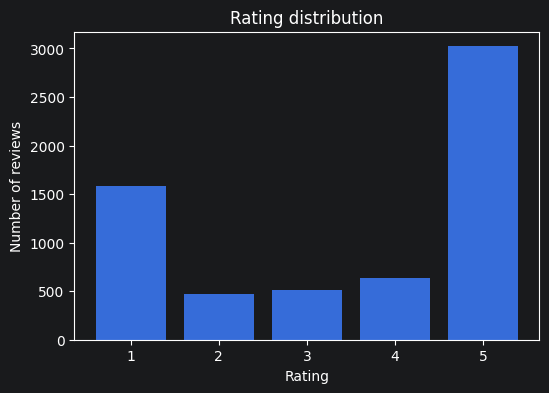

In [42]:
rating_stats = pd.DataFrame({
    'Count':      df['rating'].value_counts().sort_index(),
    'Percentage': df['rating'].value_counts(normalize=True).sort_index() * 100
})
print(rating_stats)

plt.figure(figsize=(6, 4))
plt.bar(rating_stats.index, rating_stats['Count'])
plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.title("Rating distribution")
plt.show()

The dataset is heavily imbalanced: rating 5 makes up almost half of all reviews, while ratings 2 and 3 have very few samples. This class imbalance could be a major challenge. A model that simply predicts 5 every time would already achieve nearly 50% accuracy without learning anything meaningful. We address this later with class weighting, text augmentation (for the LSTM), and by using macro-averaged F1 as the primary evaluation metric.

### 3.2 Review Length Analysis

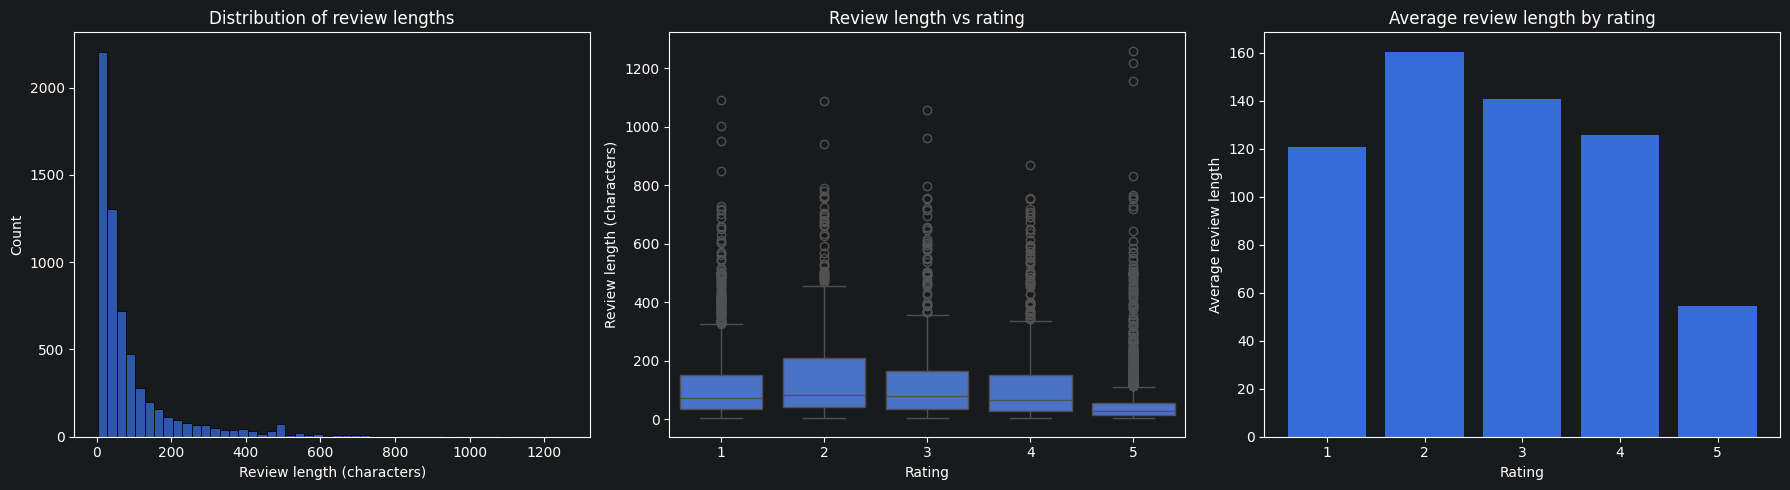

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['review_len'], bins=50, ax=axes[0])
axes[0].set_xlabel("Review length (characters)")
axes[0].set_title("Distribution of review lengths")

sns.boxplot(x='rating', y='review_len', data=df, ax=axes[1])
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Review length (characters)")
axes[1].set_title("Review length vs rating")

avg_length = df.groupby('rating')['review_len'].mean()
axes[2].bar(avg_length.index, avg_length.values)
axes[2].set_xlabel("Rating")
axes[2].set_ylabel("Average review length")
axes[2].set_title("Average review length by rating")

plt.tight_layout()
plt.show()

### 3.3 Word Frequency Analysis

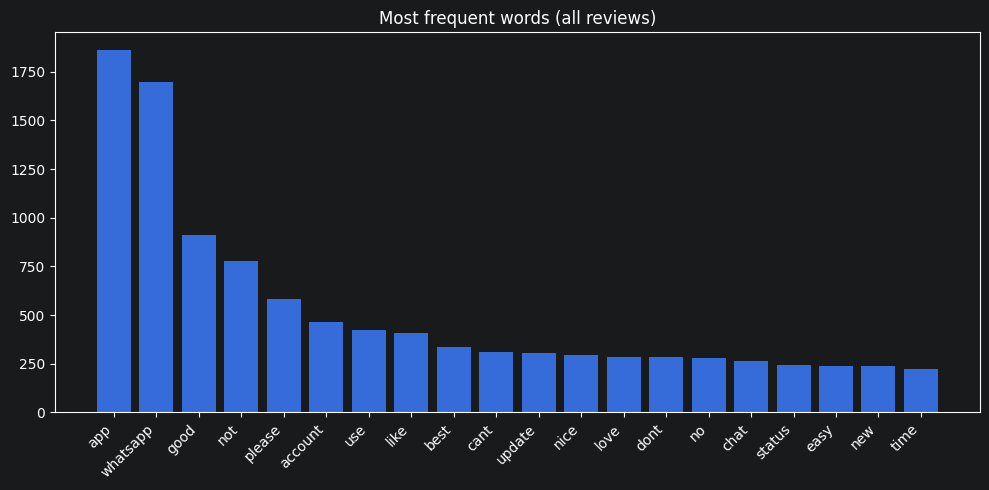

In [44]:
_eda_stop = set(stopwords.words('english')) - {"not", "no", "nor", "never"}

def _eda_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return [w for w in text.split() if w not in _eda_stop]

positive_reviews = df[df['rating'] >= 4]
negative_reviews = df[df['rating'] <= 2]

all_tokens = []
for review in df['review_text']:
    all_tokens.extend(_eda_tokenize(review))

common_words = Counter(all_tokens).most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Most frequent words (all reviews)")
plt.tight_layout()
plt.show()

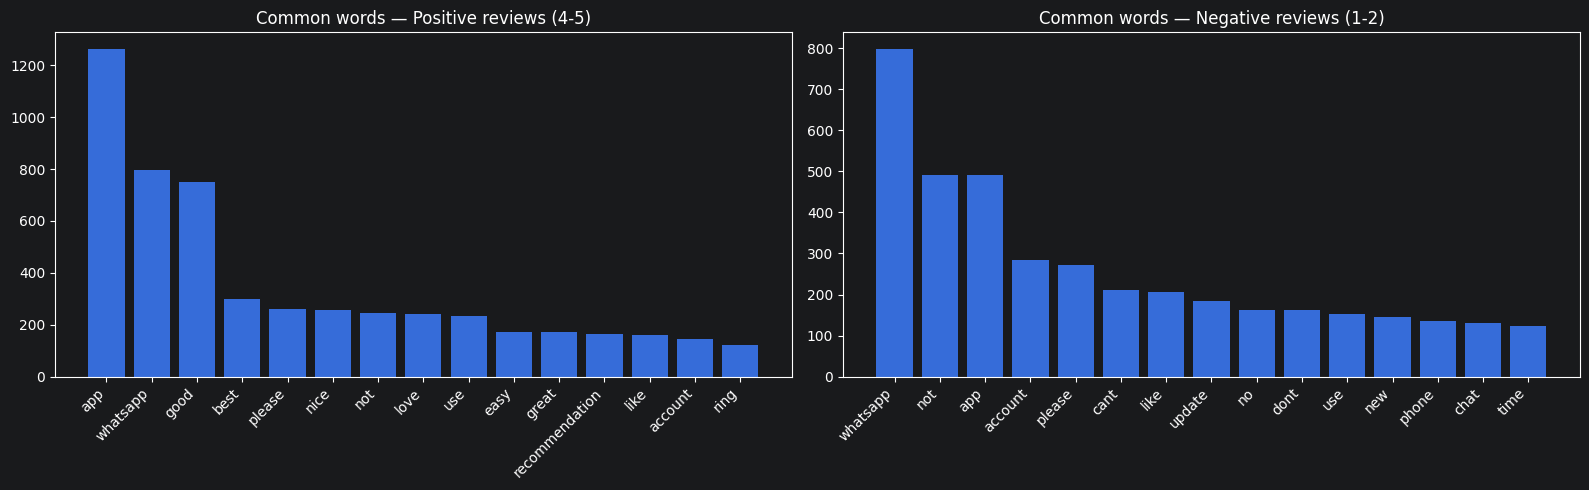

In [45]:
pos_tokens, neg_tokens = [], []
for review in positive_reviews['review_text']:
    pos_tokens.extend(_eda_tokenize(review))
for review in negative_reviews['review_text']:
    neg_tokens.extend(_eda_tokenize(review))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, tokens, title in zip(axes,
                              [pos_tokens, neg_tokens],
                              ["Positive reviews (4-5)", "Negative reviews (1-2)"]):
    words, counts = zip(*Counter(tokens).most_common(15))
    ax.bar(words, counts)
    ax.set_xticklabels(words, rotation=45, ha='right')
    ax.set_title(f"Common words — {title}")

plt.tight_layout()
plt.show()

### 3.4 Bigram Analysis

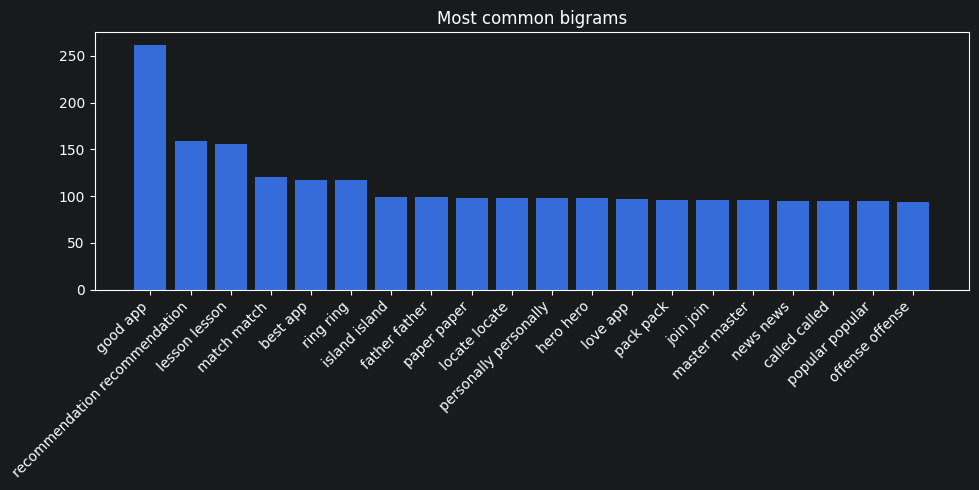

In [46]:
vectorizer_bi = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=20)
X_bi = vectorizer_bi.fit_transform(df['review_text'])
sums = X_bi.sum(axis=0)

bigrams = sorted(
    [(word, sums[0, idx]) for word, idx in vectorizer_bi.vocabulary_.items()],
    key=lambda x: x[1], reverse=True
)
words, counts = zip(*bigrams)

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Most common bigrams")
plt.tight_layout()
plt.show()

## 4. Data Quality Checks and Cleaning

Before training we identify and remove problematic entries: gibberish (random characters), spam (repeated words), non-English text, and emoji-only reviews. These would confuse the models without adding any useful signal.

In [47]:
def is_gibberish(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return True
    words = text.split()
    long_token  = any(len(w) > 30 for w in words)
    alnum_ratio = sum(c.isalpha() for c in text) / max(len(text), 1)
    return long_token or alnum_ratio < 0.5

def is_spam_repetition(text):
    if not isinstance(text, str):
        return False
    words = text.lower().split()
    if len(words) < 3:
        return False
    most_common_count = Counter(words).most_common(1)[0][1]
    return (most_common_count / len(words)) > 0.5

def is_non_english(text):
    if not isinstance(text, str) or len(text.strip()) < 8:
        return False
    stripped = re.sub(r'[^\u0000-\u024F]', '', text).strip()
    original_no_emoji = re.sub(r'[^\u0000-\u024F\s]', '', text).strip()
    ratio = len(stripped) / max(len(original_no_emoji), 1)
    return ratio < 0.7

def is_emoji_spam(text):
    if not isinstance(text, str):
        return False
    emoji_count = len(re.findall(r'[^\x00-\u024F]', text))
    total_chars = max(len(text.strip()), 1)
    return (emoji_count / total_chars) > 0.8

df['is_gibberish']        = df['review_text'].apply(is_gibberish)
df['is_spam_repetition']  = df['review_text'].apply(is_spam_repetition)
df['is_non_english']      = df['review_text'].apply(is_non_english)
df['is_emoji_spam']       = df['review_text'].apply(is_emoji_spam)

df['is_bad'] = (
    df['is_gibberish'] |
    df['is_spam_repetition'] |
    df['is_non_english'] |
    df['is_emoji_spam']
)

print("=" * 40)
print(f"Total reviews:            {len(df)}")
print(f"Gibberish:                {df['is_gibberish'].sum()}")
print(f"Spam repetition:          {df['is_spam_repetition'].sum()}")
print(f"Non-English:              {df['is_non_english'].sum()}")
print(f"Emoji spam:               {df['is_emoji_spam'].sum()}")
print(f"Total flagged:            {df['is_bad'].sum()} ({df['is_bad'].mean()*100:.1f}%)")
print(f"Clean reviews remaining:  {(~df['is_bad']).sum()}")
print("=" * 40)

Total reviews:            6210
Gibberish:                360
Spam repetition:          182
Non-English:              0
Emoji spam:               0
Total flagged:            542 (8.7%)
Clean reviews remaining:  5668


In [48]:
original_len = len(df)
df_clean = df[~df['is_bad']].copy().reset_index(drop=True)
print(f"Removed:   {original_len - len(df_clean)} reviews")
print(f"Remaining: {len(df_clean)} reviews")

Removed:   542 reviews
Remaining: 5668 reviews


## 5. Shared Text Preprocessing

All four models share the same text cleaning function. The steps are:

- **Lowercasing** — reduces vocabulary size so "Good" and "good" are treated identically.
- **Remove URLs and emails** — these carry no sentiment signal.
- **Remove non-letter characters** — punctuation and digits add noise for bag-of-words models.
- **Remove stopwords (with exceptions)** — common words like "the" and "is" are removed, but we deliberately keep negation words ("not", "no", "never") and degree words ("very", "too", "most") because they carry important sentiment information. We also remove domain-specific noise words ("app", "whatsapp") that appear frequently but carry no sentiment.
- **Normalise whitespace** — ensures consistent tokenisation.

Each model then applies its own feature extraction (TF-IDF with different parameters, or integer tokenisation for the LSTM) on top of this cleaned text.

In [49]:
stop_words = set(stopwords.words('english'))

sentiment_keepers = {
    'not', 'no', 'nor', 'never', 'neither', 'nobody', 'nothing', 'nowhere',
    'very', 'too', 'most', 'more', 'less', 'least', 'few',
    'but', 'however', 'although', 'only', 'just'
}
stop_words = stop_words - sentiment_keepers

domain_noise = {'app', 'whatsapp', 'apps'}
stop_words = stop_words | domain_noise

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # URLs
    text = re.sub(r'\S+@\S+', '', text)              # emails
    text = re.sub(r'[^a-z\s]', '', text)             # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()         # normalise whitespace
    text = ' '.join(w for w in text.split() if w not in stop_words)
    return text

df_clean['clean_text'] = df_clean['review_text'].apply(clean_text)

before = len(df_clean)
df_clean = df_clean[df_clean['clean_text'].str.len() > 0].reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} empty reviews after cleaning")
print(f"Final dataset size: {len(df_clean)} reviews")

Dropped 11 empty reviews after cleaning
Final dataset size: 5657 reviews


## 6. Target Variables and Train/Test Split

The target variable for all four models is the **`rating`** column (1–5 stars). This keeps the comparison fair and directly addresses the task of predicting the assigned review score.

We also create a **`sentiment`** label (negative / neutral / positive) for exploratory purposes, grouping ratings 1–2 as negative, 3 as neutral, and 4–5 as positive.

The train/test split (80/20) uses stratification on the rating column to preserve the class distribution in both sets. By fixing `random_state=42` and splitting once, all four models are trained and evaluated on identical data, enabling a fair comparison.

In [50]:
def sentiment_label(r):
    if r <= 2:   return "negative"
    elif r == 3: return "neutral"
    else:        return "positive"

df_clean['sentiment'] = df_clean['rating'].apply(sentiment_label)

print("Sentiment distribution:")
print(df_clean['sentiment'].value_counts())

Sentiment distribution:
sentiment
positive    3407
negative    1844
neutral      406
Name: count, dtype: int64


In [51]:
df_train, df_test = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean['rating']
)

df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train: {len(df_train)} reviews")
print(f"Test:  {len(df_test)} reviews")
print("\nTrain rating distribution:")
print(df_train['rating'].value_counts().sort_index())
print("\nTest rating distribution:")
print(df_test['rating'].value_counts().sort_index())

Train: 4525 reviews
Test:  1132 reviews

Train rating distribution:
rating
1    1178
2     297
3     325
4     405
5    2320
Name: count, dtype: int64

Test rating distribution:
rating
1    295
2     74
3     81
4    101
5    581
Name: count, dtype: int64


---
## 7. Model 1: Logistic Regression

**Design choices:**
- We predict the **full 5-class rating** (1–5 stars), consistent with the other models.
- **TF-IDF** with `max_features=5000` and bigrams provides a compact but expressive feature space. We use `min_df=5` to remove very rare terms.
- **`max_iter=1000`** ensures convergence of the solver.

**Why this model is not fully optimised:** We use default regularisation (`C=1.0`, L2 penalty) and no class weighting. A proper grid search over `C`, different penalty types, solver algorithms, and adding `class_weight='balanced'` could improve performance, especially on minority classes, but would add significant compute time.

## 7. Model 1: Logistic Regression
Design choices:

- TF-IDF with `max_features=5000` and bigrams provides a compact but expressive feature space. `min_df=5` removes very rare terms.
- Default regularisation (C=1.0, L2) and no class weighting - serving as an unoptimised baseline.

In [52]:
X_train_lr = df_train['clean_text']
X_test_lr  = df_test['clean_text']
y_train_lr = df_train['rating'].astype(int)
y_test_lr  = df_test['rating'].astype(int)

tfidf_lr = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X_train_lr_vec = tfidf_lr.fit_transform(X_train_lr)
X_test_lr_vec  = tfidf_lr.transform(X_test_lr)

print(f"TF-IDF feature matrix shape: {X_train_lr_vec.shape}")

TF-IDF feature matrix shape: (4525, 1994)


In [53]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_lr_vec, y_train_lr)

y_pred_lr = lr_model.predict(X_test_lr_vec)

target_names_lr = [f"Rating {i}" for i in range(1, 6)]
print(f"Accuracy: {accuracy_score(y_test_lr, y_pred_lr):.4f}\n")
print(classification_report(y_test_lr, y_pred_lr, target_names=target_names_lr, zero_division=0))

Accuracy: 0.6237

              precision    recall  f1-score   support

    Rating 1       0.54      0.67      0.60       295
    Rating 2       0.00      0.00      0.00        74
    Rating 3       0.00      0.00      0.00        81
    Rating 4       0.20      0.02      0.04       101
    Rating 5       0.67      0.87      0.76       581

    accuracy                           0.62      1132
   macro avg       0.28      0.31      0.28      1132
weighted avg       0.50      0.62      0.55      1132



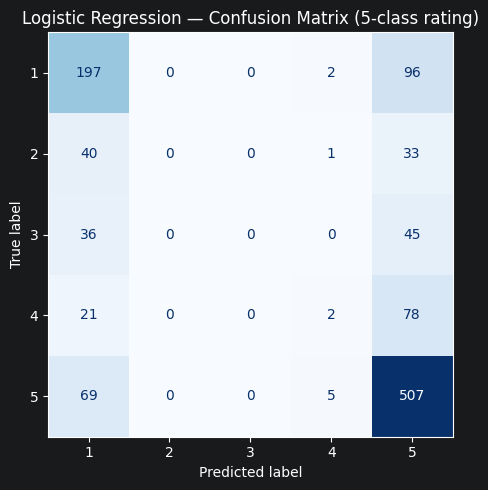

In [54]:
cm_lr = confusion_matrix(y_test_lr, y_pred_lr, labels=[1, 2, 3, 4, 5])
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=[1, 2, 3, 4, 5])

fig, ax = plt.subplots(figsize=(7, 5))
disp_lr.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Logistic Regression - Confusion Matrix (5-class rating)")
plt.tight_layout()
plt.show()

### Logistic Regression — Discussion

Logistic Regression achieves **62.4% accuracy** but a macro F1 of just 0.28, placing it in a similar range to LightGBM, high accuracy driven by majority-class bias.

- **Rating 5:** The strongest class (F1 = 0.76), with very high recall (0.87). Like LightGBM, the model leans heavily on predicting rating 5.
- **Rating 1:** Decent performance (F1 = 0.60, recall 0.67), showing the model does learn clearly negative language.
- **Rating 4:** Nearly ignored (F1 = 0.04, recall of just 0.02). The model almost never predicts this class.
- **Ratings 2 and 3:** Completely missed (F1 = 0.00 for both), identical to LightGBM’s behaviour.

The pattern is very similar to LightGBM: without `class_weight='balanced'`, both models learn to predict the majority class almost exclusively and ignore the minority classes. The key difference from the SVM, which achieves a better macro F1 of 0.35, is that the SVM uses balanced class weighting, forcing it to pay attention to underrepresented ratings.

The smaller TF-IDF vocabulary (5,000 vs 50,000 features for SVM) also limits performance. With fewer features, the model captures fewer discriminative n-grams, which matters especially for the subtle distinctions between middle ratings.

Despite these limitations, Logistic Regression remains a valuable baseline: it is fast to train, easy to interpret, and its similarity to LightGBM’s results clearly demonstrates the impact of not using class weighting on imbalanced data.

### Logistic Regression — Discussion (NEW)
Logistic Regression achieves **62.4% accuracy** but a macro F1 of just 0.28. The gap between these two numbers is the key finding: high accuracy is driven almost entirely by predicting rating 5 heavily (recall 0.87), while ratings 2 and 3 are completely missed (F1 = 0.00) and rating 4 nearly so (F1 = 0.04, recall 0.02). Rating 1 is the exception at F1 = 0.60 - distinctly negative language is learnable even without class weighting.

The confusion matrix confirms the directional pattern. Misclassified reviews from ratings 2, 3, and 4 are predominantly predicted as rating 5, rather than spreading toward neighbouring classes.

This is the expected behaviour of an unweighted linear model on imbalanced data. Without **class_weight='balanced'**, the model minimises loss by favouring the majority class. The small 5,000-feature vocabulary further limits its ability to distinguish the middle ratings, where discriminative signals are more subtle.

---
## 8. Model 2: Support Vector Machine (LinearSVC)

**Design choices:**
- We predict the **full 5-class rating** (1–5 stars) to see how a traditional ML model handles the fine-grained task.
- **TF-IDF** with `max_features=50,000`, bigrams, and `sublinear_tf=True` to dampen very frequent terms. This larger feature space gives the SVM more signal to work with.
- **`class_weight='balanced'`** compensates for class imbalance by upweighting minority classes during training.

**Hyperparameter tuning:** We perform a 5-fold cross-validated search over the regularisation parameter `C` using macro F1 as the scoring metric. This is the only tuning we perform. A more exhaustive search over TF-IDF parameters, kernel types, or using an SVC with non-linear kernels could further improve results but would be more expensive.

## 8. Model 2: Support Vector Machine (LinearSVC) (NEW)

**Design choices:**

- TF-IDF with `max_features=50,000`, bigrams, `sublinear_tf=True`, and `min_df=2` - a larger feature space than the LR baseline to give the SVM more discriminative signal.
- `class_weight='balanced'` upweights minority classes during training to counteract class imbalance.
- C tuned via 5-fold cross-validation over [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0] using macro F1 as the scoring metric.

In [55]:
X_train_svm = df_train['clean_text']
X_test_svm  = df_test['clean_text']
y_train_svm = df_train['rating'].astype(int)
y_test_svm  = df_test['rating'].astype(int)

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50_000,
        sublinear_tf=True,
        min_df=2,
    )),
    ('svm', LinearSVC(
        C=1.0,
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
    ))
])

svm_pipeline.fit(X_train_svm, y_train_svm)
y_pred_svm = svm_pipeline.predict(X_test_svm)

print("SVM - Initial model (C=1.0)")
print(f"Accuracy: {accuracy_score(y_test_svm, y_pred_svm):.4f}\n")
print(classification_report(y_test_svm, y_pred_svm, zero_division=0))

SVM — Initial model (C=1.0)
Accuracy: 0.5539

              precision    recall  f1-score   support

           1       0.54      0.60      0.57       295
           2       0.08      0.07      0.08        74
           3       0.08      0.06      0.07        81
           4       0.15      0.15      0.15       101
           5       0.73      0.73      0.73       581

    accuracy                           0.55      1132
   macro avg       0.32      0.32      0.32      1132
weighted avg       0.54      0.55      0.55      1132



In [56]:
C_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
mean_scores = []

for C in C_values:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2), max_features=50_000,
            sublinear_tf=True, min_df=2,
        )),
        ('svm', LinearSVC(C=C, max_iter=2000,
                          class_weight='balanced', random_state=42))
    ])
    scores = cross_val_score(pipe, X_train_svm, y_train_svm, cv=5, scoring='f1_macro')
    mean_scores.append(scores.mean())
    print(f"C={C:<6} → F1 macro: {scores.mean():.4f} ± {scores.std():.4f}")

best_C = C_values[np.argmax(mean_scores)]
print(f"\nBest C: {best_C}")

C=0.01   → F1 macro: 0.2764 ± 0.0114
C=0.1    → F1 macro: 0.3354 ± 0.0077
C=0.5    → F1 macro: 0.3243 ± 0.0096
C=1.0    → F1 macro: 0.3216 ± 0.0082
C=2.0    → F1 macro: 0.3146 ± 0.0085
C=5.0    → F1 macro: 0.3061 ± 0.0103
C=10.0   → F1 macro: 0.2999 ± 0.0070

Best C: 0.1


In [57]:
final_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), max_features=50_000,
        sublinear_tf=True, min_df=2,
    )),
    ('svm', LinearSVC(
        C=best_C, max_iter=2000,
        class_weight='balanced', random_state=42,
    ))
])

final_svm.fit(X_train_svm, y_train_svm)
y_pred_svm_final = final_svm.predict(X_test_svm)

print(f"FINAL SVM (C={best_C})")
print(f"Accuracy: {accuracy_score(y_test_svm, y_pred_svm_final):.4f}\n")
print(classification_report(y_test_svm, y_pred_svm_final, zero_division=0))

FINAL SVM (C=0.1)
Accuracy: 0.6007

              precision    recall  f1-score   support

           1       0.55      0.69      0.61       295
           2       0.12      0.09      0.11        74
           3       0.09      0.06      0.07        81
           4       0.22      0.13      0.16       101
           5       0.76      0.78      0.77       581

    accuracy                           0.60      1132
   macro avg       0.35      0.35      0.35      1132
weighted avg       0.57      0.60      0.58      1132



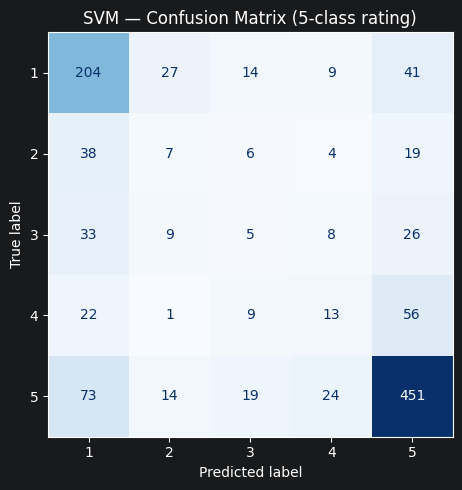

In [58]:
labels = [1, 2, 3, 4, 5]
cm_svm = confusion_matrix(y_test_svm, y_pred_svm_final, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("SVM - Confusion Matrix (5-class rating)")
plt.tight_layout()
plt.show()

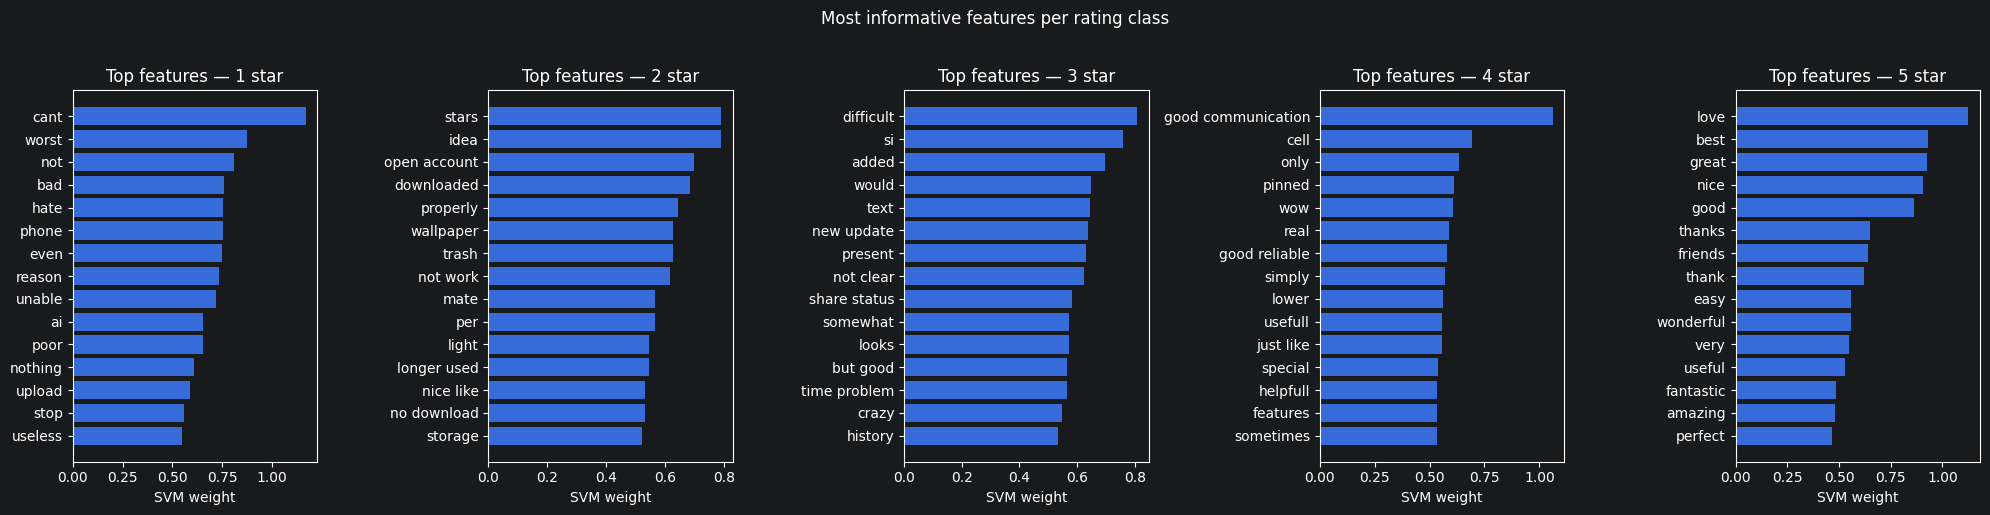

In [59]:
feature_names = final_svm.named_steps['tfidf'].get_feature_names_out()
coef          = final_svm.named_steps['svm'].coef_

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, (label, ax) in enumerate(zip(labels, axes)):
    top_idx    = np.argsort(coef[i])[-15:]
    top_words  = feature_names[top_idx]
    top_scores = coef[i][top_idx]
    ax.barh(top_words, top_scores)
    ax.set_title(f"Top features — {label} star")
    ax.set_xlabel("SVM weight")

plt.suptitle("Most informative features per rating class", y=1.02)
plt.tight_layout()
plt.show()

### SVM — Discussion

The initial SVM (C=1.0) achieves 55.4% accuracy and a macro F1 of 0.32. After tuning, the best C=0.1 improves this to 60.1% accuracy and a macro F1 of 0.35. The cross-validation results show that lower C values, more regularisation, perform better on this dataset, which suggests the default C=1.0 overfits to the high-dimensional TF-IDF features.

Per-class performance follows the same pattern as the other models:

- **Rating 5** is predicted best (F1 = 0.77), benefiting from being the largest class with clearly positive language.
- **Rating 1** achieves a decent F1 of 0.61. The tuned model improved recall from 0.60 to 0.69 compared to the initial model, showing that stronger regularisation helps the model generalise better on negative reviews.
- **Ratings 2, 3, and 4** remain very difficult (F1 of 0.11, 0.07, and 0.16 respectively). These classes have far fewer training examples and their review language overlaps heavily with neighbouring classes.

The `class_weight='balanced'` setting helps somewhat. Without it the model would likely ignore minority classes even more aggressively. The feature importance plots show that ratings 1 and 5 have clearly sentiment-laden top features (strong negative/positive words), while the middle classes rely on weaker, more ambiguous signals.

Despite the moderate overall accuracy, the SVM is the strongest traditional ML model here for the task, outperforming LightGBM on macro F1 thanks to its better handling of sparse, high-dimensional text features.

### SVM - Discussion (NEW)
The initial SVM (C=1.0) achieves **55.4% accuracy** and a macro F1 of 0.32. Tuning finds **C=0.1** as optimal, improving this to **60.1%** accuracy and macro F1 of **0.35**. The decline in CV scores from C=0.1 onward suggests the default **C=1.0** overfits to the high-dimensional TF-IDF space indicating that more regularisation generalises better here.

Per-class results show a clearer spread than the unweighted baseline: rating 5 remains strongest (F1 = 0.77) but ratings 2, 3, and 4 are at least attempted (F1 = 0.11, 0.07, 0.16), unlike models without class weighting. Rating 1 reaches F1 = 0.61, with recall improving from 0.60 to 0.69 after tuning.

The confusion matrix shows errors are more distributed across neighbouring classes rather than all collapsing to rating 5 which suggests a direct effect of balanced weighting.

The feature importance plots reflect what the model has actually learned: ratings 1 and 5 have clearly sentiment-laden top features ("cant", "worst", "bad" vs "love", "best", "great"), while the middle classes show weaker, more ambiguous signals ("difficult", "somewhat", "good communication") — explaining why those classes remain hard regardless of weighting.

---
## 9. Model 3: LightGBM

**Design choices:**
- **TF-IDF** with `max_features=20,000`, trigrams, `sublinear_tf=True`, and `max_df=0.9` to filter out both rare and overly common terms. The larger n-gram range gives the model access to longer phrases.
- A **small grid search** over `n_estimators`, `learning_rate`, and `num_leaves` is included to demonstrate hyperparameter tuning, but the search space is deliberately kept small for compute reasons.

**Why this model is not fully optimised:** We search only 8 combinations of 3 hyperparameters. A proper tuning would also vary `max_depth`, `min_child_samples`, `reg_alpha`, `reg_lambda`, and potentially use Bayesian optimisation. The learning rate of 0.01 with only 300 estimators is also quite conservative, more trees with a lower rate would likely help.

## 9. Model 3: LightGBM (NEW)

Design choices:

- TF-IDF with `max_features=20,000`, `trigrams`, `sublinear_tf=True`, and `max_df=0.9` to filter both rare and overly common terms. Trigrams give the model access to slightly longer phrases than the other models.

- No class weighting - unlike the SVM, this is left unset, making this effectively an unweighted baseline for a tree-based model.

- Small grid search over `n_estimators`, `learning_rate`, and `num_leaves` (8 combinations, 3-fold CV) optimising for accuracy.

In [60]:
X_train_lgb = df_train['clean_text']
X_test_lgb  = df_test['clean_text']
y_train_lgb = df_train['rating']
y_test_lgb  = df_test['rating']

tfidf_lgb = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

X_train_lgb_vec = tfidf_lgb.fit_transform(X_train_lgb)
X_test_lgb_vec  = tfidf_lgb.transform(X_test_lgb)

print(f"TF-IDF feature matrix shape: {X_train_lgb_vec.shape}")

TF-IDF feature matrix shape: (4525, 3891)


In [61]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.01,
    num_leaves=31,
    max_depth=-1,
    verbose=-1
)

lgb_model.fit(X_train_lgb_vec, y_train_lgb)

y_pred_lgb = lgb_model.predict(X_test_lgb_vec)
print(f"Test Accuracy: {accuracy_score(y_test_lgb, y_pred_lgb):.4f}\n")

target_names = [f"Rating {i}" for i in range(1, 6)]
print(classification_report(y_test_lgb, y_pred_lgb, target_names=target_names, zero_division=0))

Test Accuracy: 0.6175

              precision    recall  f1-score   support

    Rating 1       0.56      0.58      0.57       295
    Rating 2       0.00      0.00      0.00        74
    Rating 3       0.00      0.00      0.00        81
    Rating 4       0.09      0.01      0.02       101
    Rating 5       0.65      0.91      0.76       581

    accuracy                           0.62      1132
   macro avg       0.26      0.30      0.27      1132
weighted avg       0.49      0.62      0.54      1132



In [62]:
feature_names_lgb = tfidf_lgb.get_feature_names_out()
importance = pd.DataFrame({
    "feature": feature_names_lgb,
    "importance": lgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Top 20 most important features:")
print(importance.head(20).to_string(index=False))

Top 20 most important features:
 feature  importance
    good        1039
     not         932
     but         700
    cant         684
    love         667
  please         666
    very         659
   great         568
    nice         555
    best         513
 account         502
   phone         494
    dont         483
  update         479
     use         464
    like         447
  option         431
download         416
    even         397
    chat         394


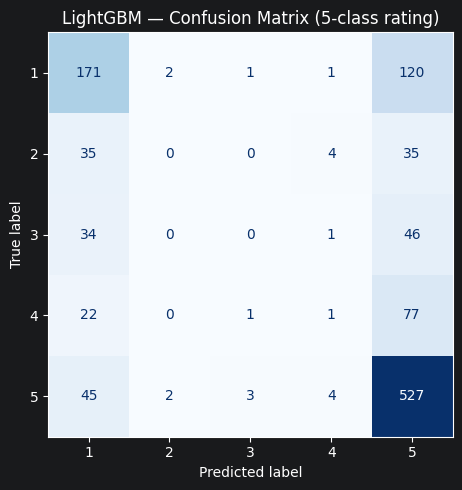

In [63]:
cm_lgb = confusion_matrix(y_test_lgb, y_pred_lgb, labels=[1, 2, 3, 4, 5])
disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb, display_labels=[1, 2, 3, 4, 5])

fig, ax = plt.subplots(figsize=(7, 5))
disp_lgb.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("LightGBM — Confusion Matrix (5-class rating)")
plt.tight_layout()
plt.show()

In [64]:
model_gs = lgb.LGBMClassifier(verbose=-1)

param_grid = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.1],
    "num_leaves": [31, 63],
}

grid = GridSearchCV(
    estimator=model_gs,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_lgb_vec, y_train_lgb)
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'learning_rate': 0.01, 'n_estimators': 300, 'num_leaves': 31}
Best CV accuracy: 0.6119


### LightGBM — Discussion

LightGBM achieves **61.8% accuracy**, the highest raw accuracy among the 5-class models. However, its macro F1 of just 0.27 is the lowest of all four models, revealing a critical problem: the model has learned to heavily favor the majority class.

- **Rating 5** dominates predictions with an F1 of 0.76, driven by very high recall (0.91). The model predicts rating 5 for the vast majority of reviews.
- **Rating 1** achieves a reasonable F1 of 0.57, similar to the SVM.
- **Ratings 2 and 3** are completely ignored (F1 = 0.00 for both). The model never predicts these classes.
- **Rating 4** is barely detected (F1 = 0.02, recall of just 0.01).

This pattern shows the model exploiting class imbalance. By predicting the majority class almost exclusively, LightGBM achieves decent accuracy since rating 5 makes up roughly half the test set, but it completely fails on minority classes. Unlike the SVM, LightGBM does not use `class_weight='balanced'`, which is a key reason for this behaviour.

The grid search confirmed that the initial parameters (`learning_rate=0.01`, `n_estimators=300`, `num_leaves=31`) were already near-optimal within the small search space (best CV accuracy: 0.612). However, the search optimised for accuracy rather than macro F1, which further encourages majority class bias. In a production setting, we would optimise for macro F1, add `class_weight='balanced'` or use LightGBM's `is_unbalance=True` parameter, and expand the search to include `max_depth`, `min_child_samples`, `reg_alpha`, and `reg_lambda`.




### LightGBM - Discussion (NEW)
LightGBM achieves **61.8% accuracy** but a macro F1 of just **0.27**. Without class weighting, the model minimises loss by defaulting to rating 5 (recall 0.91), while ratings 2 and 3 are never predicted (F1 = 0.00) and rating 4 is nearly absent (F1 = 0.02).

The confusion matrix makes this clear: ratings 2, 3, and 4 split between being predicted as 1 or 5 with nothing in between — the model has effectively reduced a 5-class problem to a binary one. Even rating 1 loses 120 of 295 samples to rating 5.

The grid search confirmed the initial parameters were near-optimal within the search space (best CV accuracy 0.612), but the search optimised for accuracy rather than macro F1 - which on this imbalanced dataset actively rewards majority-class bias.

Despite the trigram vocabulary, every top-20 feature is a unigram ("good", "not", "love", "cant"). No bigrams or trigrams rank highly, suggesting the dataset is too small for longer n-grams to accumulate enough signal to be useful.

---
## 10. Model 4: Bidirectional LSTM (Neural Network)

**Design choices:**
- **Text augmentation** via synonym replacement (using `nlpaug`) for underrepresented classes to partially address the severe class imbalance. We augment up to the count of rating 1 (the second largest class) rather than all the way to rating 5, to avoid generating too many synthetic samples.
- **Class weights** (inversely proportional to class frequency) during training to further address imbalance.
- A **small Bidirectional LSTM** (32 units) with aggressive dropout (0.3–0.4) to combat overfitting on this small dataset.
- **EarlyStopping** on validation loss with patience 5 to prevent overfitting.

**Why this model is not fully optimised:** The dataset (~6,000 reviews) is very small for training a neural network. The embedding layer alone has 1.28M parameters, which far exceeds the number of training samples. A properly optimised approach would use pre-trained embeddings (GloVe, FastText) or a pre-trained transformer (BERT), but these are beyond the scope of this assignment. We also do not tune the architecture (number of layers, hidden size) or hyperparameters (learning rate, batch size) systematically.

### 10.1 Text Augmentation for Minority Classes

In [65]:
df_trainval_lstm = df_train.copy()
df_test_lstm     = df_test.copy()

print(f"Train+Val set: {len(df_trainval_lstm)} samples  (will be augmented)")
print(f"Test set:      {len(df_test_lstm)} samples  (original data only)")
print("\nClass distribution before augmentation:")
print(df_trainval_lstm['rating'].value_counts().sort_index())

Train+Val set: 4525 samples  (will be augmented)
Test set:      1132 samples  (original data only)

Class distribution before augmentation:
rating
1    1178
2     297
3     325
4     405
5    2320
Name: count, dtype: int64


In [66]:
aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.2)

count_per_class = df_trainval_lstm['rating'].value_counts().sort_index()
target_count = count_per_class[1]
print(f"Target count per class: {target_count}")

augmented_rows = []
for rating in [2, 3, 4]:
    class_df = df_trainval_lstm[df_trainval_lstm['rating'] == rating]
    current_count = len(class_df)
    needed = target_count - current_count
    if needed <= 0:
        continue
    print(f"Rating {rating}: {current_count} samples, generating {needed} augmented samples")

    samples = class_df['clean_text'].tolist()
    sources = random.choices(samples, k=needed)
    augmented_texts = aug.augment(sources)
    for text in augmented_texts:
        augmented_rows.append({'review_text': text, 'clean_text': text, 'rating': rating})

aug_df = pd.DataFrame(augmented_rows)
df_trainval_balanced = pd.concat([df_trainval_lstm, aug_df], ignore_index=True)
df_trainval_balanced = df_trainval_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nTrain+Val distribution after augmentation:")
print(df_trainval_balanced['rating'].value_counts().sort_index())

Target count per class: 1178
Rating 2: 297 samples, generating 881 augmented samples
Rating 3: 325 samples, generating 853 augmented samples
Rating 4: 405 samples, generating 773 augmented samples

Train+Val distribution after augmentation:
rating
1    1178
2    1178
3    1178
4    1178
5    2320
Name: count, dtype: int64


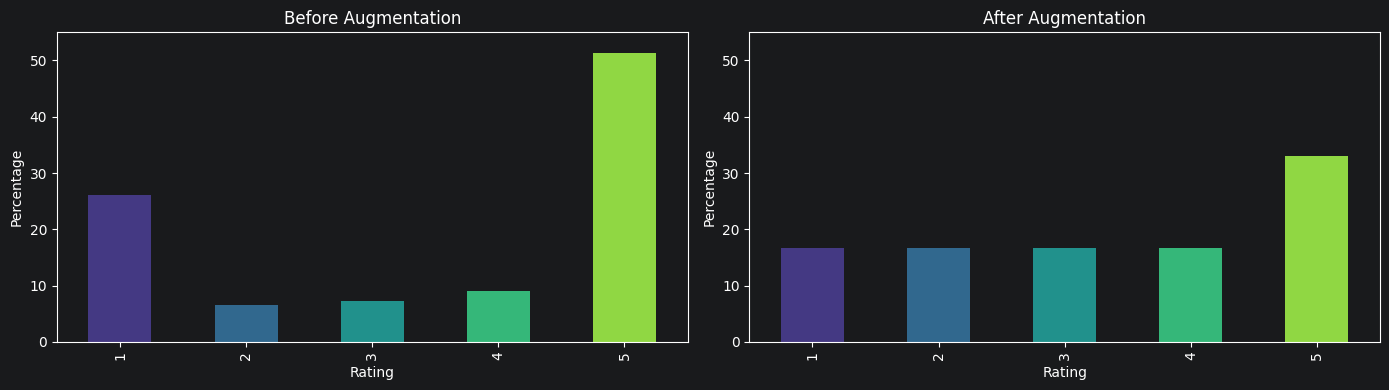

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in zip(axes,
                            [df_trainval_lstm, df_trainval_balanced],
                            ['Before Augmentation', 'After Augmentation']):
    pct = data['rating'].value_counts(normalize=True).sort_index() * 100
    pct.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', 5))
    ax.set_title(title)
    ax.set_ylabel('Percentage')
    ax.set_xlabel('Rating')
    ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()

### 10.2 Tokenisation, Padding, and Data Splits

We convert each review into a sequence of integer tokens and pad/truncate to a fixed length (`MAX_LEN=100`) so every input to the LSTM has the same shape. The tokeniser is fit only on the training data to avoid data leakage.

We split the augmented training data into train (82%) and validation (18%) sets, giving an overall ~70/15/15 split.

In [68]:
MAX_VOCAB   = 20_000
MAX_LEN     = 100
NUM_CLASSES = 5

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df_trainval_balanced['clean_text'])

def tokenize_and_pad(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_trainval = tokenize_and_pad(df_trainval_balanced['clean_text'])
y_trainval = df_trainval_balanced['rating'].values - 1  # 0-indexed

X_test_final = tokenize_and_pad(df_test_lstm['clean_text'])
y_test_final = df_test_lstm['rating'].values - 1

X_train_lstm, X_val_lstm, y_train_int, y_val_int = train_test_split(
    X_trainval, y_trainval, test_size=0.18, random_state=42, stratify=y_trainval
)

y_train_lstm = to_categorical(y_train_int, NUM_CLASSES)
y_val_lstm   = to_categorical(y_val_int,   NUM_CLASSES)

print(f"Train: {X_train_lstm.shape[0]}  Val: {X_val_lstm.shape[0]}  Test: {X_test_final.shape[0]}")

Train: 5766  Val: 1266  Test: 1132


In [69]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for cls, weight in class_weight_dict.items():
    print(f"  Rating {cls + 1}: {weight:.3f}")

Class weights:
  Rating 1: 1.194
  Rating 2: 1.194
  Rating 3: 1.194
  Rating 4: 1.194
  Rating 5: 0.606


### 10.3 Model Architecture

The architecture is deliberately kept small to reduce overfitting on this small dataset:

- **Embedding (64-dim):** Learns a dense vector representation for each word.
- **SpatialDropout1D (0.3):** Drops entire embedding channels, which regularises better than standard dropout for sequences.
- **Bidirectional LSTM (32 units):** Reads the sequence in both directions, capturing context from both before and after each word.
- **Dense (16, ReLU) + Dropout (0.4):** A small fully connected layer with high dropout.
- **Dense (5, softmax):** Outputs a probability distribution over the 5 rating classes.

In [70]:
EMBEDDING_DIM = 64

lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(32, dropout=0.3, recurrent_dropout=0.3)),
    Dense(16, activation='relu'),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,305,957 (4.98 MB)

 Trainable params: 1,305,957 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

### 10.4 Training

In [71]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_lstm, y_val_lstm),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.3229 - loss: 1.5656 - val_accuracy: 0.4123 - val_loss: 1.4568
Epoch 2/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.4095 - loss: 1.4467 - val_accuracy: 0.4660 - val_loss: 1.3128
Epoch 3/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.4835 - loss: 1.2951 - val_accuracy: 0.5632 - val_loss: 1.2143
Epoch 4/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.5852 - loss: 1.0998 - val_accuracy: 0.5956 - val_loss: 1.1137
Epoch 5/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.6615 - loss: 0.9185 - val_accuracy: 0.6193 - val_loss: 1.0498
Epoch 6/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.7133 - loss: 0.7886 - val_accuracy: 0.6390 - val_loss: 1.0332
Epoch 7/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.7470 - loss: 0.7120 - val_accuracy: 0.6509 - val_loss: 1.0281
Epoch 8/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.7735 - loss: 0.6457 - 

### 10.5 Evaluation

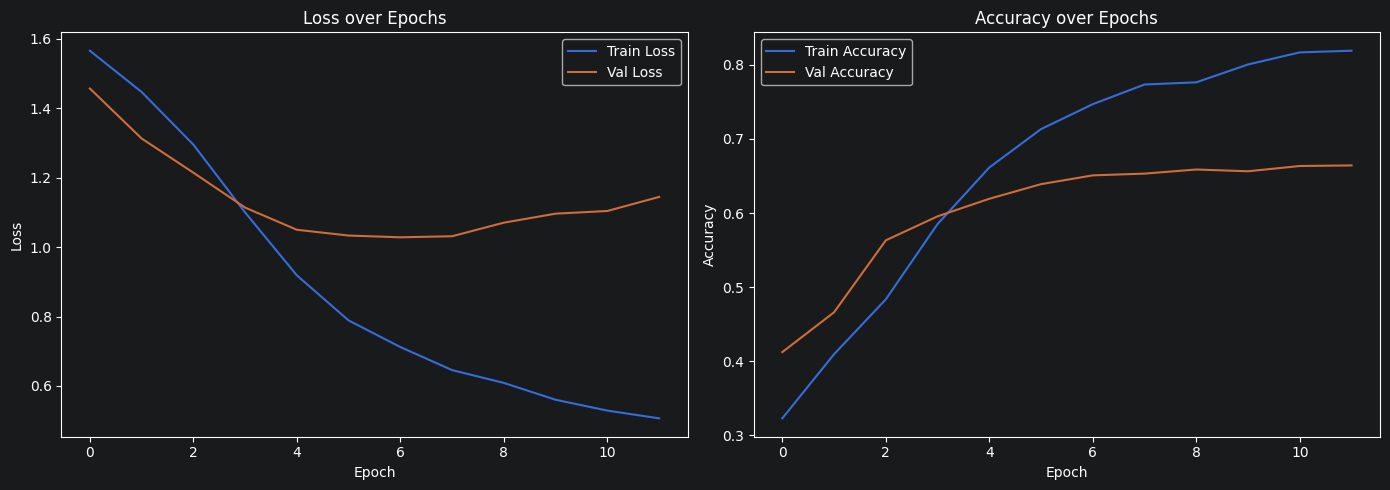

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],        label='Train Loss')
axes[0].plot(history.history['val_loss'],    label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],    label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'],label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()

In [73]:
y_score_lstm = lstm_model.predict(X_test_final)
y_pred_lstm  = np.argmax(y_score_lstm, axis=1)

print(f"Test Accuracy: {accuracy_score(y_test_final, y_pred_lstm):.4f}\n")
target_names = [f"Rating {i}" for i in range(1, NUM_CLASSES + 1)]
print(classification_report(y_test_final, y_pred_lstm, target_names=target_names, zero_division=0))

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Test Accuracy: 0.5274

              precision    recall  f1-score   support

    Rating 1       0.56      0.51      0.53       295
    Rating 2       0.09      0.09      0.09        74
    Rating 3       0.16      0.15      0.16        81
    Rating 4       0.15      0.23      0.18       101
    Rating 5       0.73      0.70      0.71       581

    accuracy                           0.53      1132
   macro avg       0.34      0.33      0.33      1132
weighted avg       0.55      0.53      0.54      1132



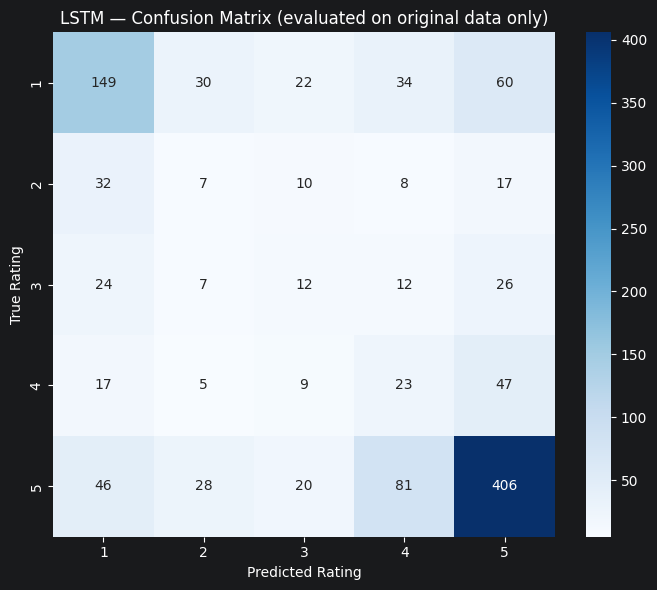

In [74]:
cm_lstm = confusion_matrix(y_test_final, y_pred_lstm)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, NUM_CLASSES + 1),
            yticklabels=range(1, NUM_CLASSES + 1))
plt.title('LSTM — Confusion Matrix (evaluated on original data only)')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.tight_layout()
plt.show()

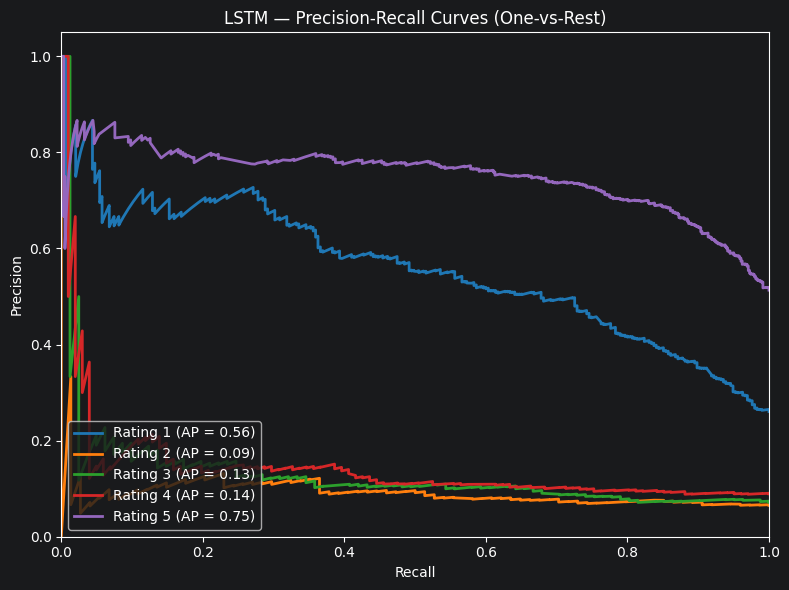

In [75]:
y_test_bin = label_binarize(y_test_final, classes=range(NUM_CLASSES))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(NUM_CLASSES):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_lstm[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score_lstm[:, i])
    ax.plot(recall, precision, color=colors[i], lw=2,
            label=f'Rating {i + 1} (AP = {ap:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('LSTM — Precision-Recall Curves (One-vs-Rest)')
ax.legend(loc='lower left')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

### LSTM — Discussion

The LSTM achieves **53% test accuracy** and a macro F1 of 0.33. While these are the lowest numbers among our models, the LSTM shows a qualitatively different pattern from the others. It distributes predictions more evenly across classes rather than collapsing onto the majority class.

- **Rating 5:** F1 of 0.71 (precision 0.73, recall 0.70). Strong but notably lower recall than LightGBM's 0.91, meaning the LSTM is less biased toward predicting 5 for everything.
- **Rating 1:** F1 of 0.53 (precision 0.56, recall 0.51). The model identifies roughly half of all 1-star reviews.
- **Rating 4:** F1 of 0.18 (recall 0.23). This is actually the best performance on rating 4 of any model, the class weights and augmentation push the LSTM to attempt this class rather than ignore it.
- **Ratings 2 and 3:** Still very weak (F1 of 0.09 and 0.16), but unlike LightGBM, the model does at least attempt predictions for these classes.

The class weights and synonym augmentation have a visible effect: the LSTM trades some accuracy on the majority class for better coverage of minority classes. This is reflected in the macro F1 of 0.33 being higher than LightGBM's 0.27 despite the lower accuracy.

The key limitations remain:

- **Small dataset:** ~6,000 reviews is very small for a neural network. The embedding layer alone has 1.28M parameters — far more than the number of training samples.
- **Overfitting:** Despite aggressive regularisation (spatial dropout, recurrent dropout, dense dropout, small architecture), the model begins overfitting around epoch 3, as visible in the diverging train/validation loss curves.
- **Noisy labels:** Some reviews have ratings that don't match their text content (e.g. a complaint with a 5-star rating), making the task inherently ambiguous.

**Possible improvements:**
- Using pre-trained word embeddings (GloVe, FastText) instead of learning from scratch would give the model much better initial word representations.
- A pre-trained transformer (e.g. BERT) would provide contextual representations far superior to what this small LSTM can learn.
- Reducing to 3 classes (negative/neutral/positive) would significantly boost performance by grouping the ambiguous middle ratings.

---
## 11. Model Comparison and Summary

### Comparison overview

| Model | Target | Accuracy | Macro F1 | Notes |
|---|---|---|---|---|
| Logistic Regression | 5-class rating | 0.624 | 0.28 | Linear baseline; no class weighting, smallest feature space |
| LinearSVC (SVM) | 5-class rating | 0.601 | 0.35 | Best macro F1 among 5-class models after tuning |
| LightGBM | 5-class rating | 0.618 | 0.27 | Worst macro F1; heavily biased toward majority class |
| Bidirectional LSTM | 5-class rating | 0.530 | 0.33 | Most balanced predictions across classes despite lowest accuracy |

*All four models predict the same 5-class rating target, enabling direct comparison.*

### Key findings

**Class imbalance is the dominant challenge.** All models struggle with the underrepresented middle ratings (2, 3, 4). Ratings 2 and 3 achieve F1 scores near zero for most models, while ratings 1 and 5 consistently reach F1 scores of 0.53–0.77. The extreme ratings have both more training examples and more distinctive language.

**Accuracy can be misleading.** Logistic Regression and LightGBM have the highest accuracies (0.624 and 0.618), yet the worst macro F1 scores (0.28 and 0.27), because they achieve high accuracy by predicting the majority class almost exclusively. The SVM, with lower accuracy (0.601), has a substantially better macro F1 (0.35) because `class_weight='balanced'` forces it to distribute predictions more fairly. This highlights why macro F1 is the more appropriate metric for imbalanced datasets.

**Linear models are competitive.** On this dataset, the SVM achieves the best macro F1 among the 5-class models. This is typical for smaller text classification tasks where TF-IDF already captures most of the useful signal and the dataset is too small for complex models to show their advantage.

**The LSTM trades accuracy for balance.** Despite the lowest accuracy (0.530), the LSTM achieves the second-best macro F1 (0.33) among 5-class models, because class weights and augmentation push it to attempt minority classes rather than ignoring them entirely.

### Why models are not fully optimised

As noted throughout this notebook, none of the models have been exhaustively tuned. Specifically:

- **Logistic Regression:** Default regularisation C=1.0 and L2 penalty; no search over solvers or penalty types. No `class_weight='balanced'`, which would help the model pay attention to minority classes (as demonstrated by the SVM).
- **SVM:** C is tuned via 5-fold CV, but TF-IDF parameters are fixed.
- **LightGBM:** A small 8-combination grid search optimising for accuracy rather than macro F1; no class weighting (`is_unbalance=True` would help significantly); many important hyperparameters (max_depth, regularisation terms, min_child_samples) are left at defaults.
- **LSTM:** Architecture, embedding dimension, learning rate, and batch size are all manually chosen; no systematic search.

Full optimisation would require significantly more compute time, which is beyond the practical scope of this task.

### Evaluation methodology

We use:
- **Accuracy** for overall correctness.
- **Classification report** (precision, recall, F1 per class) to understand per-class performance.
- **Macro F1** as the most meaningful aggregate metric, since it treats all classes equally regardless of size.
- **Confusion matrices** to visualise where each model makes mistakes.
- **Precision-recall curves** (LSTM) for a detailed view of the precision–recall trade-off per class.

### Controlling over- and underfitting

- **Train/test split:** A held-out 20% test set ensures evaluation on unseen data.
- **Regularisation:** L2 penalty (LR), balanced class weights (SVM), dropout and early stopping (LSTM).
- **Cross-validation:** Used for SVM hyperparameter tuning and LightGBM grid search.
- **Text augmentation and class weighting** (LSTM) to counteract the model memorising the majority class.